In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [2]:

# Image size
H, W = 4,4 # 8, 8

def show_image(img, title=None):
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])
    if title:
        plt.title(title)


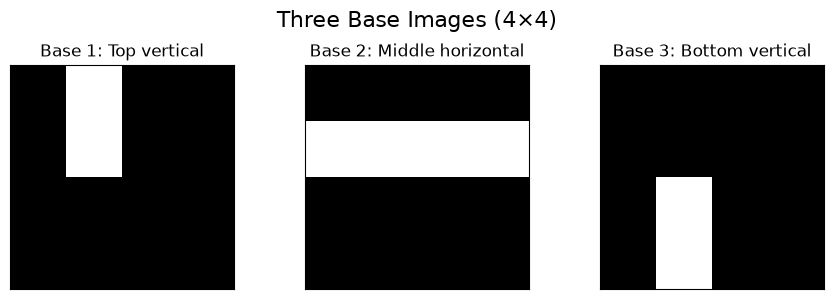

In [3]:
# --------------------------------------------------
# 1. Create 3 base images in 4x4 pixel space
# --------------------------------------------------

base_top_vertical = np.zeros((H, W))
base_middle_horizontal = np.zeros((H, W))
base_bottom_vertical = np.zeros((H, W))

# Top vertical line
base_top_vertical[0:2, 1] = 1

# Middle horizontal line
base_middle_horizontal[1, 0:4] = 1

# Bottom vertical line
base_bottom_vertical[2:4, 1] = 1

base_images = np.array([
    base_top_vertical,
    base_middle_horizontal,
    base_bottom_vertical
])

base_names = [
    "Base 1: Top vertical",
    "Base 2: Middle horizontal",
    "Base 3: Bottom vertical"
]

# Show base images
plt.figure(figsize=(9, 3))

for i, (img, name) in enumerate(zip(base_images, base_names)):
    plt.subplot(1, 3, i + 1)
    show_image(img, name)

plt.suptitle("Three Base Images (4×4)", fontsize=16)
plt.tight_layout()
plt.show()

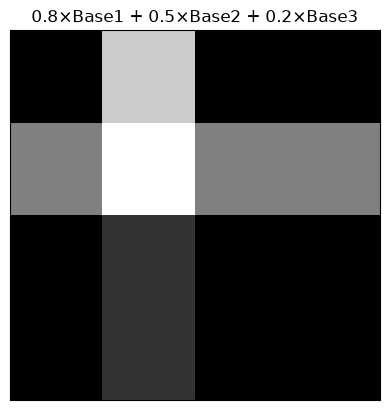

In [4]:
example = (
    0.8 * base_top_vertical +
    0.5 * base_middle_horizontal +
    0.2 * base_bottom_vertical
)

show_image(example, "0.8×Base1 + 0.5×Base2 + 0.2×Base3")

Generated images shape: (30, 4, 4)
Coefficients shape: (30, 3)


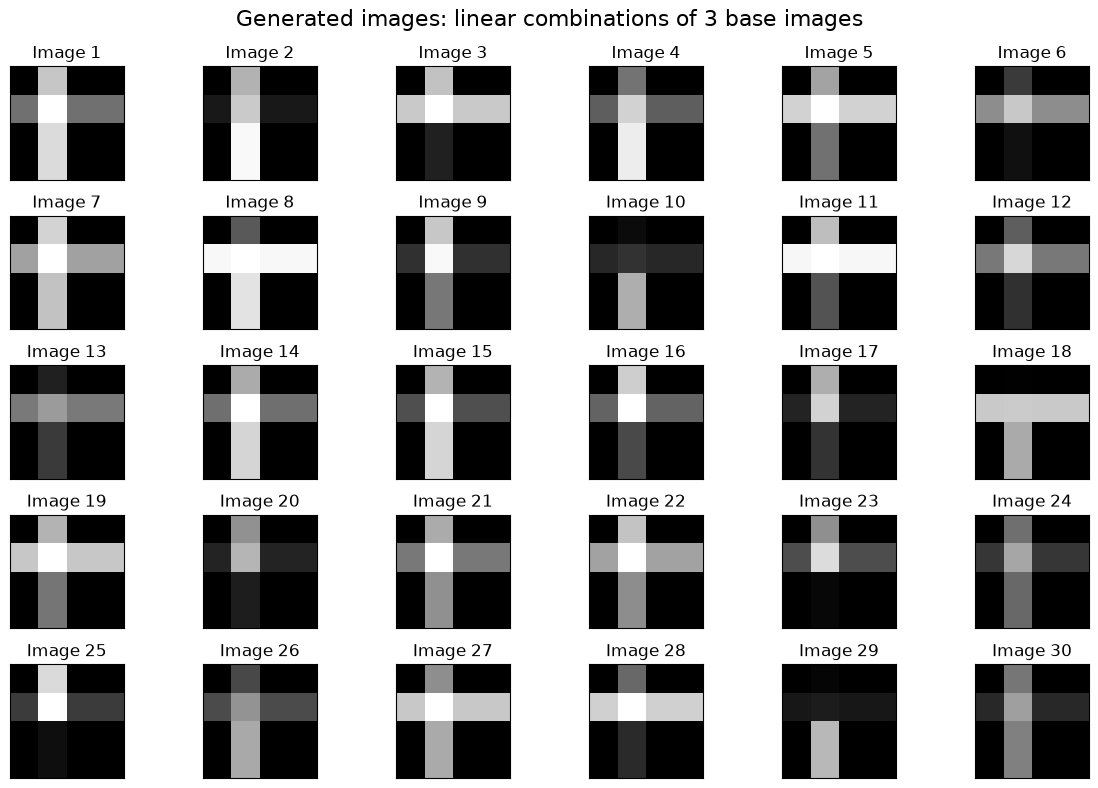

In [5]:


# --------------------------------------------------
# 2. Create random linear combinations
# --------------------------------------------------

rng = np.random.default_rng(42)

n_images = 30

# Each generated image gets 3 coefficients:
# how much of base 1, base 2, and base 3 it contains.
coefficients = rng.uniform(0, 1, size=(n_images, 3))

generated_images = []

for a, b, c in coefficients:
    img = (
        a * base_top_vertical
        + b * base_middle_horizontal
        + c * base_bottom_vertical
    )
    
    # Keep pixel values between 0 and 1 for easy display
    img = np.clip(img, 0, 1)
    generated_images.append(img)

generated_images = np.array(generated_images)

print("Generated images shape:", generated_images.shape)
print("Coefficients shape:", coefficients.shape)


# --------------------------------------------------
# 3. Show generated images
# --------------------------------------------------

plt.figure(figsize=(12, 8))

for i, img in enumerate(generated_images):
    plt.subplot(5, 6, i + 1)
    show_image(img, title=f"Image {i+1}")
    
plt.suptitle("Generated images: linear combinations of 3 base images", fontsize=16)
plt.tight_layout()
plt.show()

## PCA Story: Image → Vector → Point → New Coordinates → Reconstruction

We will use tiny 4×4 images.

Each image has:

$$ 4 \times 4 = 16 $$

pixels.

So each image can be represented as a vector with 16 numbers.

The important idea:

**Image = vector = point in a 16-dimensional space**

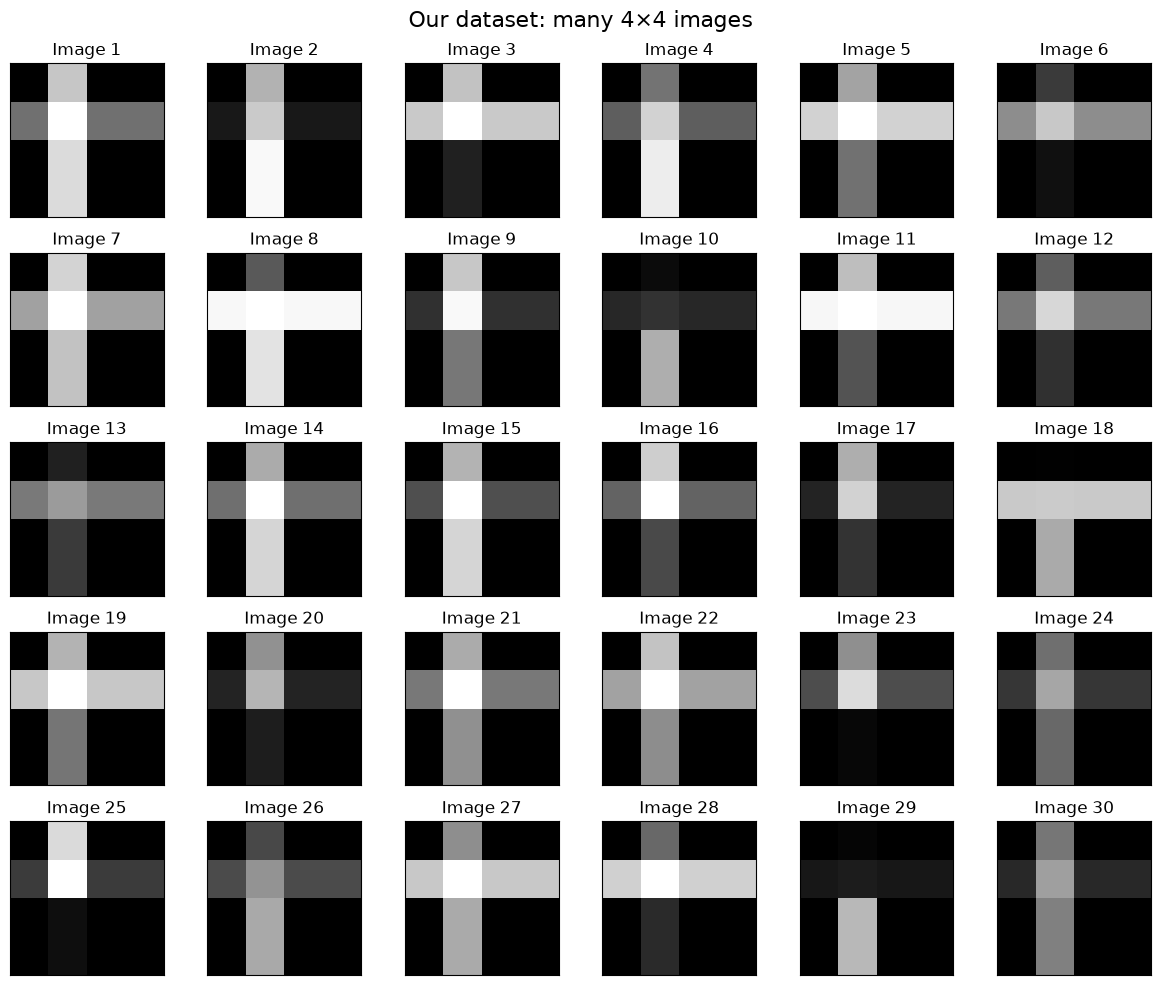

Dataset shape: (30, 4, 4)
Meaning: number of images, height, width


In [6]:
# --------------------------------------------------
# Part 1: Show the image dataset
# --------------------------------------------------

n_images = len(generated_images)

cols = 6
rows = int(np.ceil(n_images / cols))

plt.figure(figsize=(12, 2 * rows))

for i, img in enumerate(generated_images):
    plt.subplot(rows, cols, i + 1)
    show_image(img, title=f"Image {i+1}")

plt.suptitle("Our dataset: many 4×4 images", fontsize=16)
plt.tight_layout()
plt.show()

print("Dataset shape:", generated_images.shape)
print("Meaning: number of images, height, width")

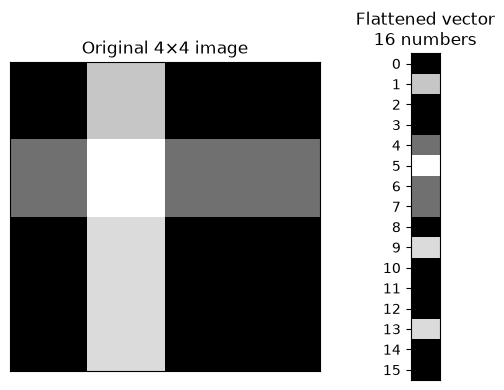

Original image shape: (4, 4)
Flattened vector shape: (16,)

Vector values:
[0.   0.77 0.   0.   0.44 1.   0.44 0.44 0.   0.86 0.   0.   0.   0.86
 0.   0.  ]


In [7]:
# --------------------------------------------------
# Part 2: Image -> Vector
# --------------------------------------------------

image_index = 0

img = generated_images[image_index]
vector = img.reshape(-1)

plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
show_image(img, title="Original 4×4 image")

plt.subplot(1, 2, 2)

plt.imshow(
    vector.reshape(-1, 1),
    cmap="gray",
    vmin=0,
    vmax=1,
    aspect=0.7   # make it much narrower
)

plt.xticks([])
plt.yticks(range(len(vector)))
plt.title("Flattened vector\n16 numbers")    
plt.tight_layout()
plt.show()

print("Original image shape:", img.shape)
print("Flattened vector shape:", vector.shape)
print()
print("Vector values:")
print(np.round(vector, 2))

In [8]:
X = generated_images.reshape(len(generated_images), -1)

print(X.shape)

(30, 16)


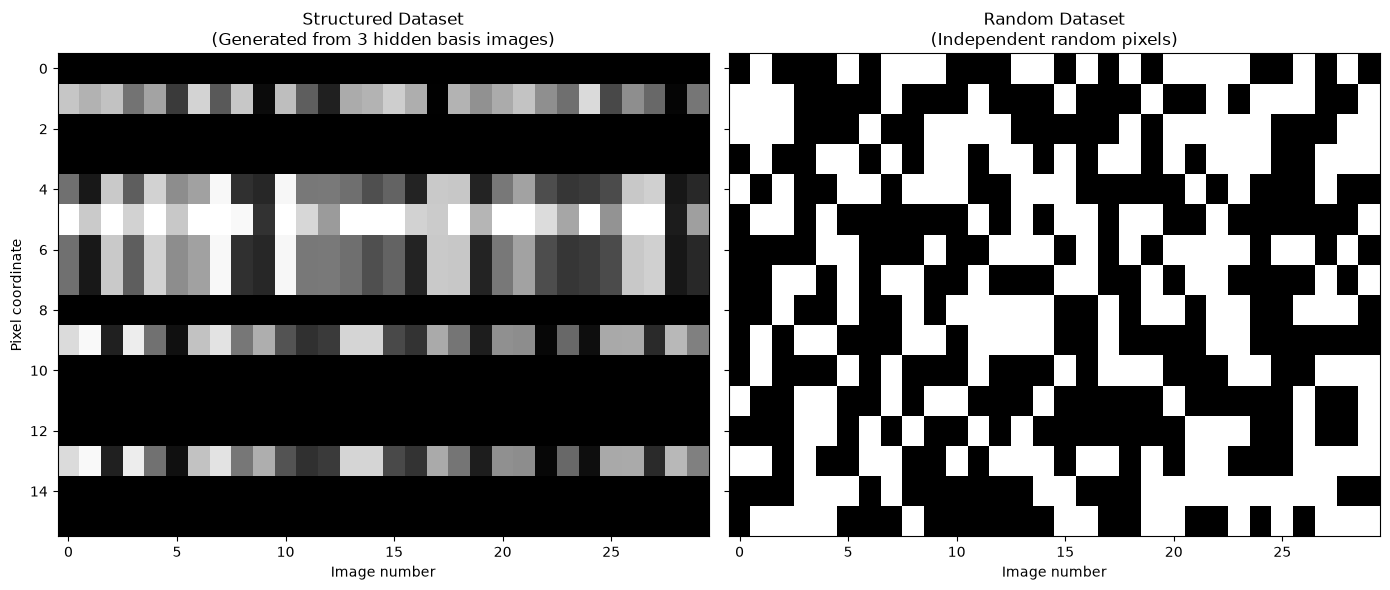

Both datasets have shape: (30, 16)

Left: strong correlation between pixels
Right: almost no correlation between pixels


In [9]:
# --------------------------------------------------
# Compare structured data vs random data
# --------------------------------------------------

# Structured dataset
X_structured = generated_images.reshape(len(generated_images), -1)

# Completely random dataset
rng = np.random.default_rng(123)

# X_random = rng.uniform(
#     low=0,
#     high=1,
#     size=X_structured.shape
# )

X_random = rng.integers(
    0,
    2,
    size=X_structured.shape
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True
)

# Structured
im1 = axes[0].imshow(
    X_structured.T,
    cmap="gray",
    aspect="auto",
    interpolation="nearest"
)

axes[0].set_title(
    "Structured Dataset\n(Generated from 3 hidden basis images)"
)
axes[0].set_xlabel("Image number")
axes[0].set_ylabel("Pixel coordinate")

# Random
im2 = axes[1].imshow(
    X_random.T,
    cmap="gray",
    aspect="auto",
    interpolation="nearest"
)

axes[1].set_title(
    "Random Dataset\n(Independent random pixels)"
)
axes[1].set_xlabel("Image number")

plt.tight_layout()
plt.show()

print("Both datasets have shape:", X_structured.shape)
print()
print("Left: strong correlation between pixels")
print("Right: almost no correlation between pixels")

In [10]:
# --------------------------------------------------
# Part 3: All images -> points in 16-dimensional space
# --------------------------------------------------

X = generated_images.reshape(n_images, -1)

print("X shape:", X.shape)
print()
print("Meaning:")
print(f"{X.shape[0]} images")
print(f"{X.shape[1]} pixels per image")
print()
print("So we now have:")
print(f"{X.shape[0]} points in {X.shape[1]}-dimensional space")

X shape: (30, 16)

Meaning:
30 images
16 pixels per image

So we now have:
30 points in 16-dimensional space


Original coordinates shape: (30, 16)
PCA coordinates shape: (30, 16)

Each row is still one image.
Each column is now a PCA coordinate.
The columns are ordered from most important to least important.


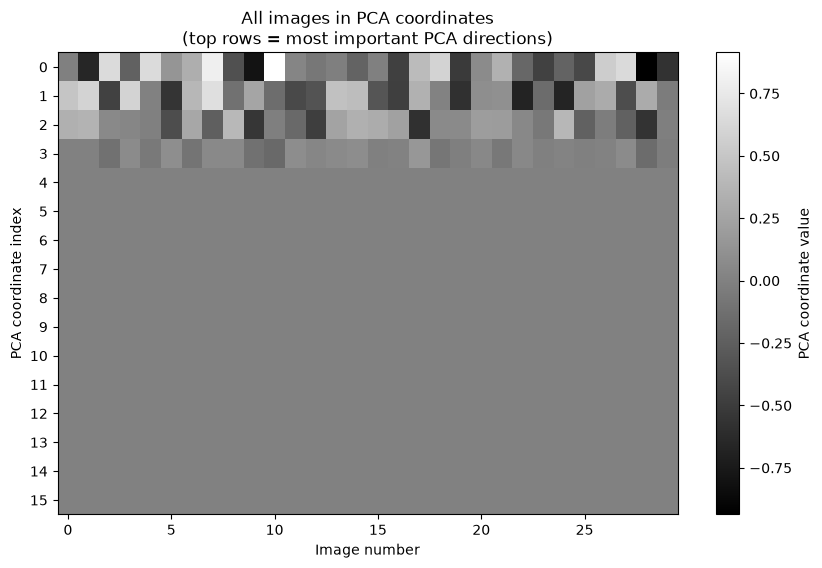

In [11]:
# --------------------------------------------------
# Part 4A: PCA creates new coordinates, ordered by importance
# --------------------------------------------------

from sklearn.decomposition import PCA

# Fit PCA with all possible components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)

print("Original coordinates shape:", X.shape)
print("PCA coordinates shape:", X_pca_full.shape)
print()
print("Each row is still one image.")
print("Each column is now a PCA coordinate.")
print("The columns are ordered from most important to least important.")

plt.figure(figsize=(10, 6))

plt.imshow(
    X_pca_full.T,
    cmap="gray",
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="PCA coordinate value")

plt.xlabel("Image number")
plt.ylabel("PCA coordinate index")
plt.title(
    "All images in PCA coordinates\n"
    "(top rows = most important PCA directions)"
)

plt.yticks(range(X_pca_full.shape[1]))

plt.show()



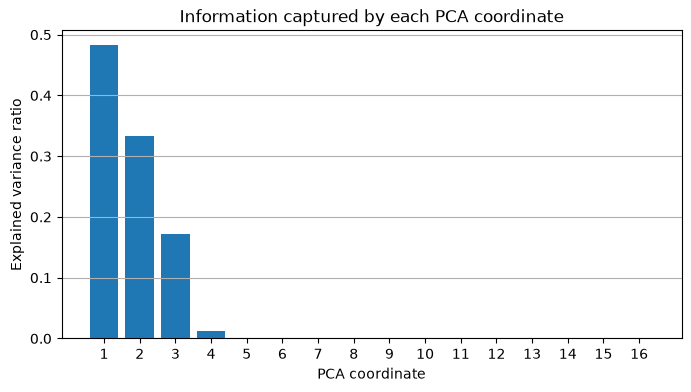

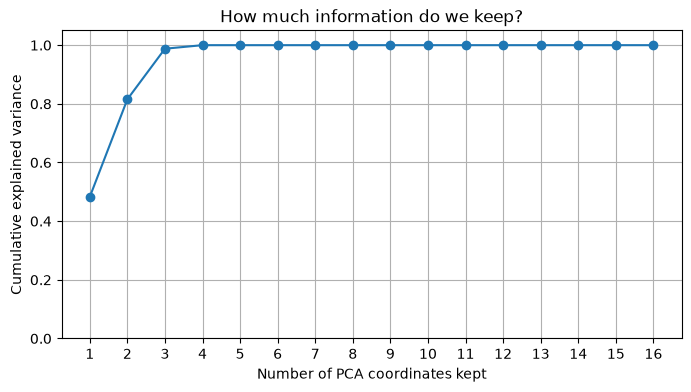

In [12]:
# --------------------------------------------------
# Part 4B: How much information does each PCA coordinate keep?
# --------------------------------------------------

plt.figure(figsize=(8, 4))

plt.bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_
)

plt.xlabel("PCA coordinate")
plt.ylabel("Explained variance ratio")
plt.title("Information captured by each PCA coordinate")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    np.cumsum(pca_full.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of PCA coordinates kept")
plt.ylabel("Cumulative explained variance")
plt.title("How much information do we keep?")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

Original coordinates shape: (30, 16)
PCA coordinates used for plot: (30, 2)

Total variance explained by 2 PCA components:
0.815


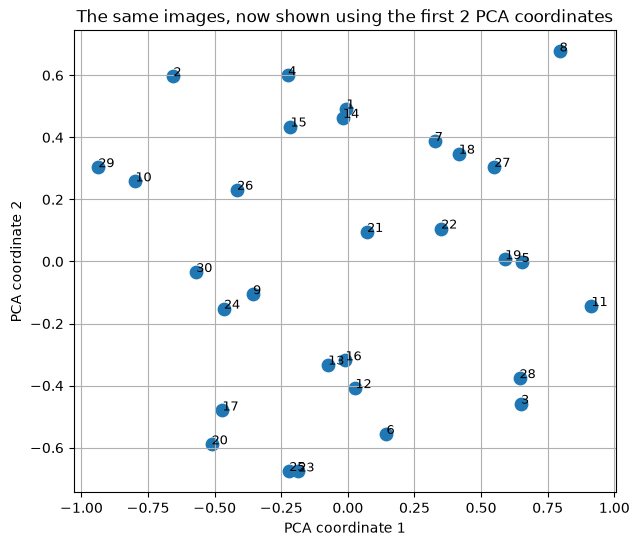

In [13]:
# --------------------------------------------------
# Part 4C: Keep only the first 2 PCA coordinates for visualization
# --------------------------------------------------

X_pca_2d = X_pca_full[:, :2]

print("Original coordinates shape:", X.shape)
print("PCA coordinates used for plot:", X_pca_2d.shape)
print()
print("Total variance explained by 2 PCA components:")
print(round(pca_full.explained_variance_ratio_[:2].sum(), 3))

plt.figure(figsize=(7, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=80)

for i in range(n_images):
    plt.text(X_pca_2d[i, 0], X_pca_2d[i, 1], str(i + 1), fontsize=9)

plt.xlabel("PCA coordinate 1")
plt.ylabel("PCA coordinate 2")
plt.title("The same images, now shown using the first 2 PCA coordinates")
plt.grid(True)
plt.show()
plt.show()

## Part 4D — Looking at the First 3 PCA Coordinates

Our original images have 16 pixel coordinates.

But the images were secretly created from only 3 hidden patterns:

1. Top vertical line
2. Middle horizontal line
3. Bottom vertical line

So we expect PCA to discover that most of the useful information lives in about 3 directions.

So we expect PCA to discover that most of the useful information comes from about 3 independent ways that the images can vary.

In our synthetic dataset these are approximately:

1. How strong is the top vertical line?
2. How strong is the middle horizontal line?
3. How strong is the bottom vertical line?

In linear algebra, each such pattern of variation is called a direction.
This does not mean the image originally had only 3 pixels.
It means PCA found 3 new coordinates that capture most of the important variation.

In [14]:
# --------------------------------------------------
# Part 4D: Show the first 3 PCA coordinates in 3D
# --------------------------------------------------

import plotly.express as px
import pandas as pd

X_pca_3d = X_pca_full[:, :3]

pca_3d_df = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Image": [f"Image {i+1}" for i in range(X_pca_3d.shape[0])]
})

fig = px.scatter_3d(
    pca_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    hover_name="Image",
    title="The same images represented by their first 3 PCA coordinates"
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    scene=dict(
        xaxis_title="PCA coordinate 1",
        yaxis_title="PCA coordinate 2",
        zaxis_title="PCA coordinate 3"
    )
)

fig.show()

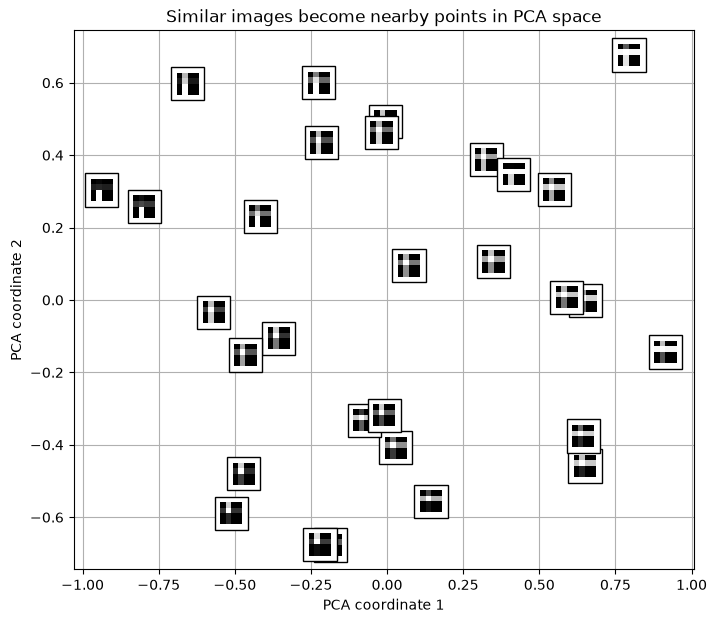

In [15]:
# --------------------------------------------------
# Part 5: Show image thumbnails inside PCA space
# --------------------------------------------------

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0)

for i, img in enumerate(generated_images):
    imagebox = OffsetImage(img, cmap="gray", zoom=4)
    ab = AnnotationBbox(
        imagebox,
        (X_pca_2d[i, 0], X_pca_2d[i, 1]),
        frameon=True
    )
    ax.add_artist(ab)

ax.set_xlabel("PCA coordinate 1")
ax.set_ylabel("PCA coordinate 2")
ax.set_title("Similar images become nearby points in PCA space")
ax.grid(True)

plt.show()

## Why do we call PCA components "directions"?

A coordinate is a number that tells us how far to move along some direction.

For example, in normal 2D space:

- The x-coordinate tells us how far to move left/right.
- The y-coordinate tells us how far to move up/down.

So the coordinate is the number, and the direction is the meaning of that number.

In our image dataset, PCA creates new coordinates.

Instead of coordinates like:

- pixel 0 brightness
- pixel 1 brightness
- pixel 2 brightness

PCA creates coordinates like:

- how much of PCA pattern 1?
- how much of PCA pattern 2?
- how much of PCA pattern 3?

Each PCA pattern is an image-shaped direction.

Changing the coordinate means moving more or less in that image direction.

So when we say:

"the data varies mostly in 3 directions"

we mean:

"most images can be described by changing only about 3 important numbers."

The direction is the pattern.

The coordinate is how much of that pattern we use.

---

This idea appears throughout modern Machine Learning.

Instead of describing an object using thousands of raw measurements, we often describe it using a small number of meaningful coordinates.

For our toy images, the coordinates might be:

- top line strength
- middle line strength
- bottom line strength

Later in the course we will see richer examples where coordinates describe things such as:

- writing style
- object shape
- face characteristics
- image content

The collection of these coordinates is often called a representation or latent space.

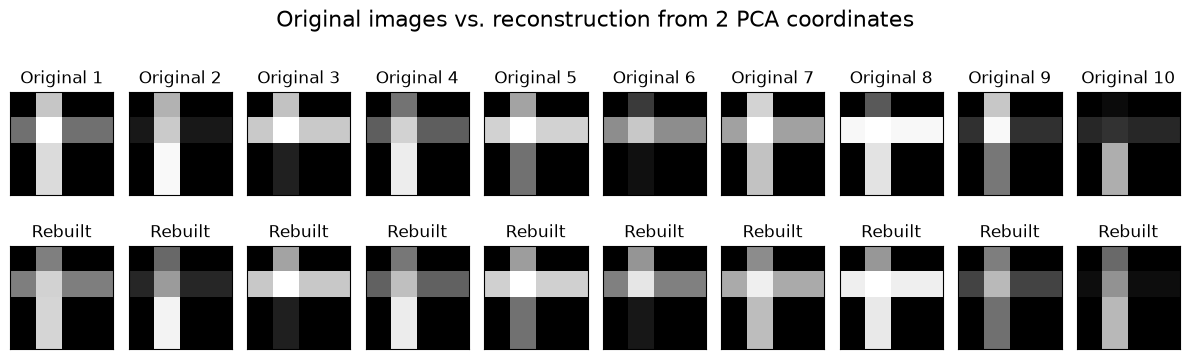

In [16]:
# --------------------------------------------------
# Part 6: Reconstruct images from only 2 PCA coordinates
# --------------------------------------------------

# Keep only the first 2 PCA coordinates
X_pca_2d = X_pca_full[:, :2]

# Create a full PCA-coordinate matrix, but set all later coordinates to zero
X_pca_2d_padded = np.zeros_like(X_pca_full)
X_pca_2d_padded[:, :2] = X_pca_2d

# Reconstruct back to pixel space
X_reconstructed = pca_full.inverse_transform(X_pca_2d_padded)

reconstructed_images = X_reconstructed.reshape(X.shape[0], H, W)

n_show = min(10, X.shape[0])

plt.figure(figsize=(12, 4))

for i in range(n_show):
    plt.subplot(2, n_show, i + 1)
    show_image(generated_images[i], title=f"Original {i+1}")

    plt.subplot(2, n_show, n_show + i + 1)
    show_image(reconstructed_images[i], title="Rebuilt")

plt.suptitle("Original images vs. reconstruction from 2 PCA coordinates", fontsize=16)
plt.tight_layout()
plt.show()

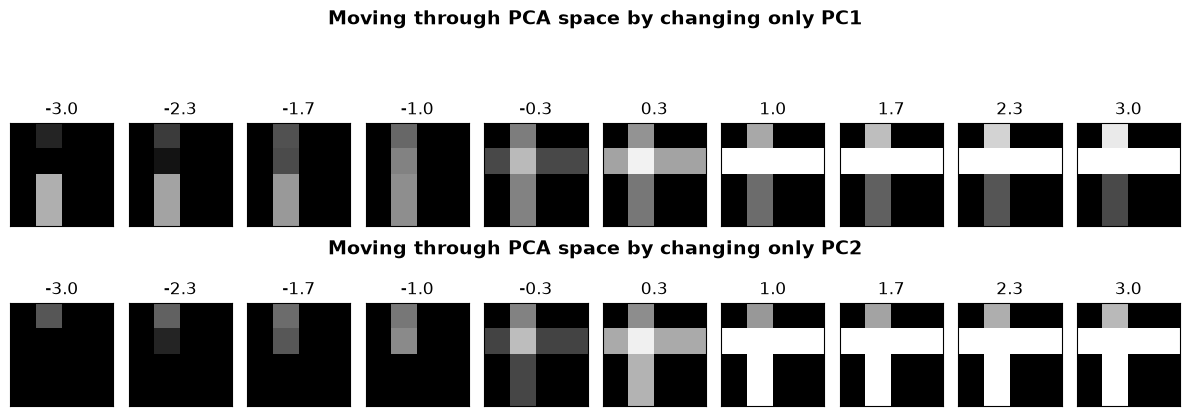

In [17]:
def reconstruct_from_pca_coordinates(pca_coords, position):
    pca_coords_full = np.zeros((1, X_pca_full.shape[1]))
    pca_coords_full[0, :(position+len(pca_coords))] = pca_coords
    reconstructed_vector = pca_full.inverse_transform(pca_coords_full)
    reconstructed_image = reconstructed_vector.reshape(H, W)
    return reconstructed_image

pc1_values = np.linspace(-3, 3, 10)
reconstructed_images_from_pc1 = []
reconstructed_images_from_pc2 = []

for pc1 in pc1_values:
    reconstructed_image = reconstruct_from_pca_coordinates([pc1], position=0)
    reconstructed_images_from_pc1.append(
        reconstructed_image
    )

for pc2 in pc1_values:
    reconstructed_image = reconstruct_from_pca_coordinates([pc2], position=1)
    reconstructed_images_from_pc2.append(
        reconstructed_image
    )


fig = plt.figure(figsize=(12, 5))

# -------------------------
# Row 1
# -------------------------

for i, img in enumerate(reconstructed_images_from_pc1):
    plt.subplot(2, len(pc1_values), i + 1)

    show_image(
        img,
        title=f"{pc1_values[i]:.1f}"
    )

# Label for row 1
fig.text(
    0.5, 0.93,
    "Moving through PCA space by changing only PC1",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

# -------------------------
# Row 2
# -------------------------

for i, img in enumerate(reconstructed_images_from_pc2):
    plt.subplot(2, len(pc1_values), len(pc1_values) + i + 1)

    show_image(
        img,
        title=f"{pc1_values[i]:.1f}"
    )

# Label between rows
fig.text(
    0.5, 0.47,
    "Moving through PCA space by changing only PC2",
    ha="center",
    fontsize=14,
    fontweight="bold"
)
    
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

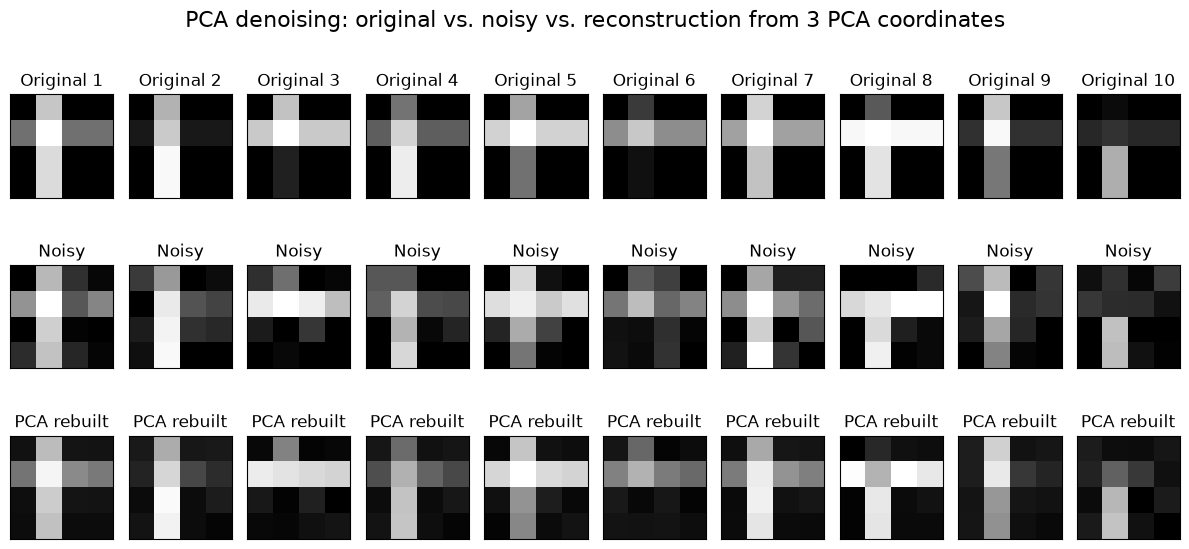

Noise level: 0.15
Explained variance ratio:
[0.379 0.253 0.173]

Total variance explained by 3 PCA components:
0.805


In [18]:
# --------------------------------------------------
# Part 7: Add noise and use PCA reconstruction as denoising
# --------------------------------------------------

rng = np.random.default_rng(123)

noise_level = 0.15

# Flatten clean images
X_clean = generated_images.reshape(n_images, -1)

# Add random noise
X_noisy = X_clean + rng.normal(
    loc=0,
    scale=noise_level,
    size=X_clean.shape
)

# Keep values in display range
X_noisy = np.clip(X_noisy, 0, 1)

noisy_images = X_noisy.reshape(n_images, H, W)

# Fit PCA on the noisy images
# We use 3 components because the clean images were created from 3 hidden base images
pca_denoise = PCA(n_components=3)

X_noisy_pca = pca_denoise.fit_transform(X_noisy)
X_denoised = pca_denoise.inverse_transform(X_noisy_pca)

# Keep reconstructed pixels in display range
X_denoised = np.clip(X_denoised, 0, 1)

denoised_images = X_denoised.reshape(n_images, H, W)

n_show = min(10, n_images)

plt.figure(figsize=(12, 6))

for i in range(n_show):
    # Original clean image
    plt.subplot(3, n_show, i + 1)
    show_image(generated_images[i], title=f"Original {i+1}")

    # Noisy image
    plt.subplot(3, n_show, n_show + i + 1)
    show_image(noisy_images[i], title="Noisy")

    # PCA reconstruction
    plt.subplot(3, n_show, 2 * n_show + i + 1)
    show_image(denoised_images[i], title="PCA rebuilt")

plt.suptitle(
    "PCA denoising: original vs. noisy vs. reconstruction from 3 PCA coordinates",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Noise level:", noise_level)
print("Explained variance ratio:")
print(np.round(pca_denoise.explained_variance_ratio_, 3))
print()
print("Total variance explained by 3 PCA components:")
print(round(pca_denoise.explained_variance_ratio_.sum(), 3))

PCA keeps the directions where many images vary together.

Random noise is spread across many pixel directions, so when we reconstruct using only a few PCA components, some of the noise disappears.

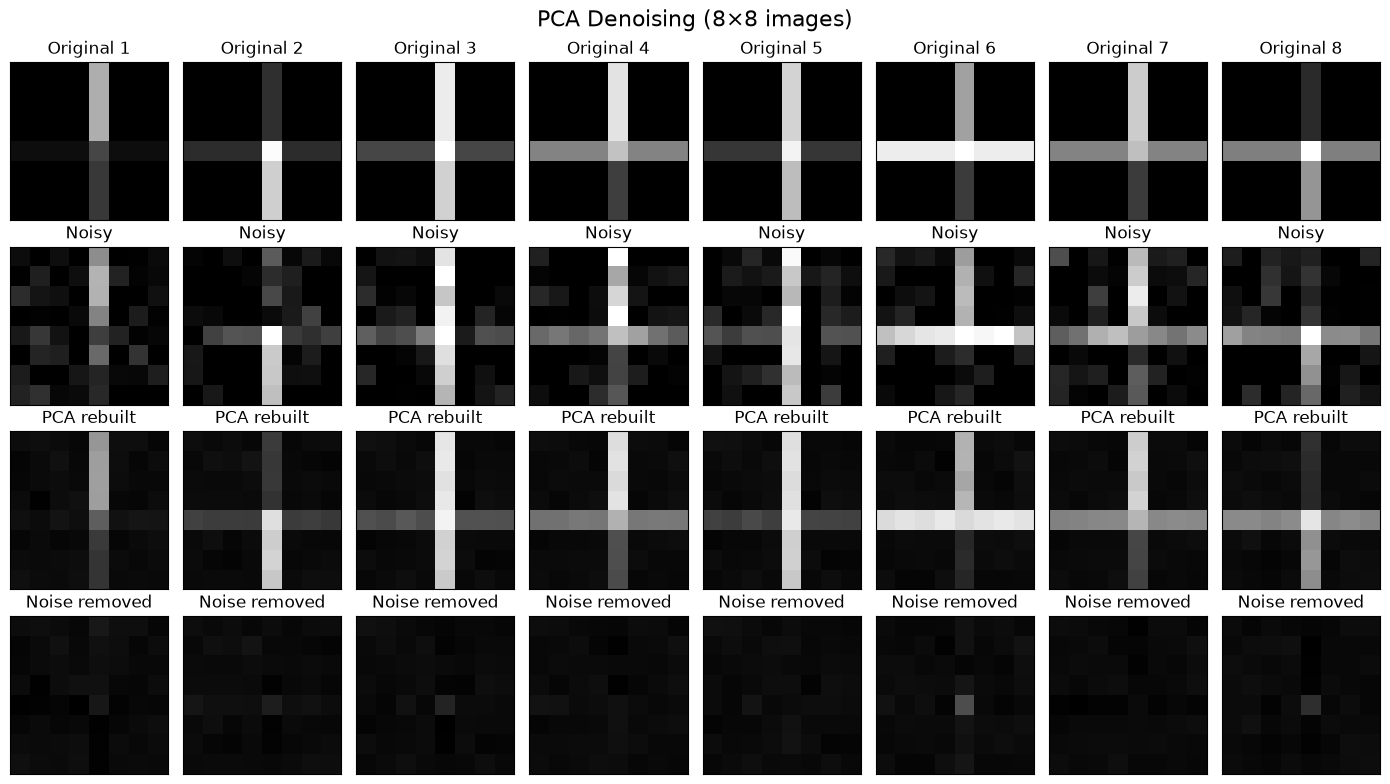

Image size: 8 x 8
Pixels per image: 64
Noise level: 0.1

Explained variance ratio:
[0.437 0.197 0.185]

Total variance explained: 0.819


In [19]:
# --------------------------------------------------
# Part 7: PCA Denoising Demo
# (independent of the earlier 4×4 PCA explanation)
# --------------------------------------------------


# ==================================================
# Change this to 8, 16, 32 ...
# ==================================================

DEMO_SIZE = 8

# ==================================================
# Create higher-resolution basis images
# ==================================================

H_demo = DEMO_SIZE
W_demo = DEMO_SIZE

base_top_vertical = np.zeros((H_demo, W_demo))
base_middle_horizontal = np.zeros((H_demo, W_demo))
base_bottom_vertical = np.zeros((H_demo, W_demo))

center_col = W_demo // 2
center_row = H_demo // 2

# Top vertical
base_top_vertical[: H_demo // 2, center_col] = 1

# Middle horizontal
base_middle_horizontal[center_row, :] = 1

# Bottom vertical
base_bottom_vertical[H_demo // 2 :, center_col] = 1

# ==================================================
# Generate clean images
# ==================================================

rng = np.random.default_rng(123)

n_images = 100

coefficients = rng.uniform(
    0,
    1,
    size=(n_images, 3)
)

clean_images = []

for a, b, c in coefficients:

    img = (
        a * base_top_vertical
        + b * base_middle_horizontal
        + c * base_bottom_vertical
    )

    clean_images.append(img)

clean_images = np.array(clean_images)

# ==================================================
# Flatten
# ==================================================

X_clean = clean_images.reshape(n_images, -1)

# ==================================================
# Add noise
# ==================================================

noise_level = 0.10

X_noisy = X_clean + rng.normal(
    loc=0,
    scale=noise_level,
    size=X_clean.shape
)

X_noisy = np.clip(X_noisy, 0, 1)

# ==================================================
# PCA denoising
# ==================================================

pca_denoise = PCA(n_components=3)

X_noisy_pca = pca_denoise.fit_transform(X_noisy)

X_denoised = pca_denoise.inverse_transform(
    X_noisy_pca
)

X_denoised = np.clip(X_denoised, 0, 1)

# ==================================================
# Back to images
# ==================================================

noisy_images = X_noisy.reshape(
    n_images,
    H_demo,
    W_demo
)

denoised_images = X_denoised.reshape(
    n_images,
    H_demo,
    W_demo
)

difference_images = np.abs(
    clean_images - denoised_images
)



# ==================================================
# Visual comparison
# ==================================================

n_show = 8

plt.figure(figsize=(14, 8))

for i in range(n_show):

    plt.subplot(4, n_show, i + 1)
    show_image(clean_images[i], title=f"Original {i+1}")

    plt.subplot(4, n_show, n_show + i + 1)
    show_image(noisy_images[i], title="Noisy")

    plt.subplot(4, n_show, 2 * n_show + i + 1)
    show_image(denoised_images[i], title="PCA rebuilt")

    plt.subplot(4, n_show, 3 * n_show + i + 1)
    show_image(difference_images[i], title="Noise removed")

plt.suptitle(
    f"PCA Denoising ({DEMO_SIZE}×{DEMO_SIZE} images)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ==================================================
# Statistics
# ==================================================

print("Image size:", DEMO_SIZE, "x", DEMO_SIZE)
print("Pixels per image:", DEMO_SIZE * DEMO_SIZE)
print("Noise level:", noise_level)

print("\nExplained variance ratio:")
print(
    np.round(
        pca_denoise.explained_variance_ratio_,
        3
    )
)

print(
    "\nTotal variance explained:",
    round(
        pca_denoise.explained_variance_ratio_.sum(),
        3
    )
)